In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv('data/cleaned_data.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [74]:
# Переименуем целевую переменную 
df.rename(columns={'Attrition': 'target'}, inplace=True)
df.columns

Index(['Age', 'target', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

In [75]:
# Преобразуем target в 0/1

df['target'] = df['target'].map({'Yes': 1, 'No': 0})

NUM_COLS = df.select_dtypes(include=['int64']).columns
CAT_COLS = df.select_dtypes(include=['str']).columns

df[NUM_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
target,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


Распределение целевой переменной:
target
0    0.839
1    0.161
Name: proportion, dtype: float64


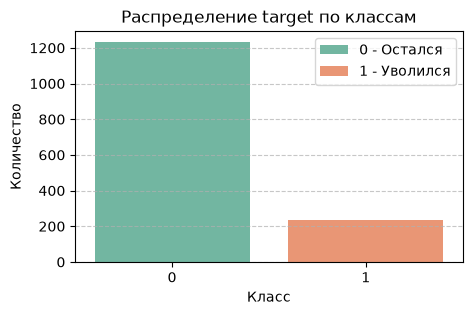

In [ ]:
print("Распределение целевой переменной:")
print(df['target'].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 3))
sns.countplot(x='target', data=df, hue='target', palette='Set2')
plt.title('Распределение target по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.legend(['0 - Остался', '1 - Уволился'])
plt.grid(axis='y', linestyle='--', alpha=0.7)  

plt.savefig('img/distribution_target.png', format='png', dpi=200, bbox_inches='tight')

## Вывод: баланс классов
- No=1233 (83.9%), Yes=237 (16.1%): сильный дисбаланс
- Следствие: метрика accuracy будет вводить в заблуждение, поэтому смотрим F1, PR-AUC, recall
- Также обязательно использовать stratify + class_weight='balanced'


## Анализ числовых признаков для ушедших и оставшихся

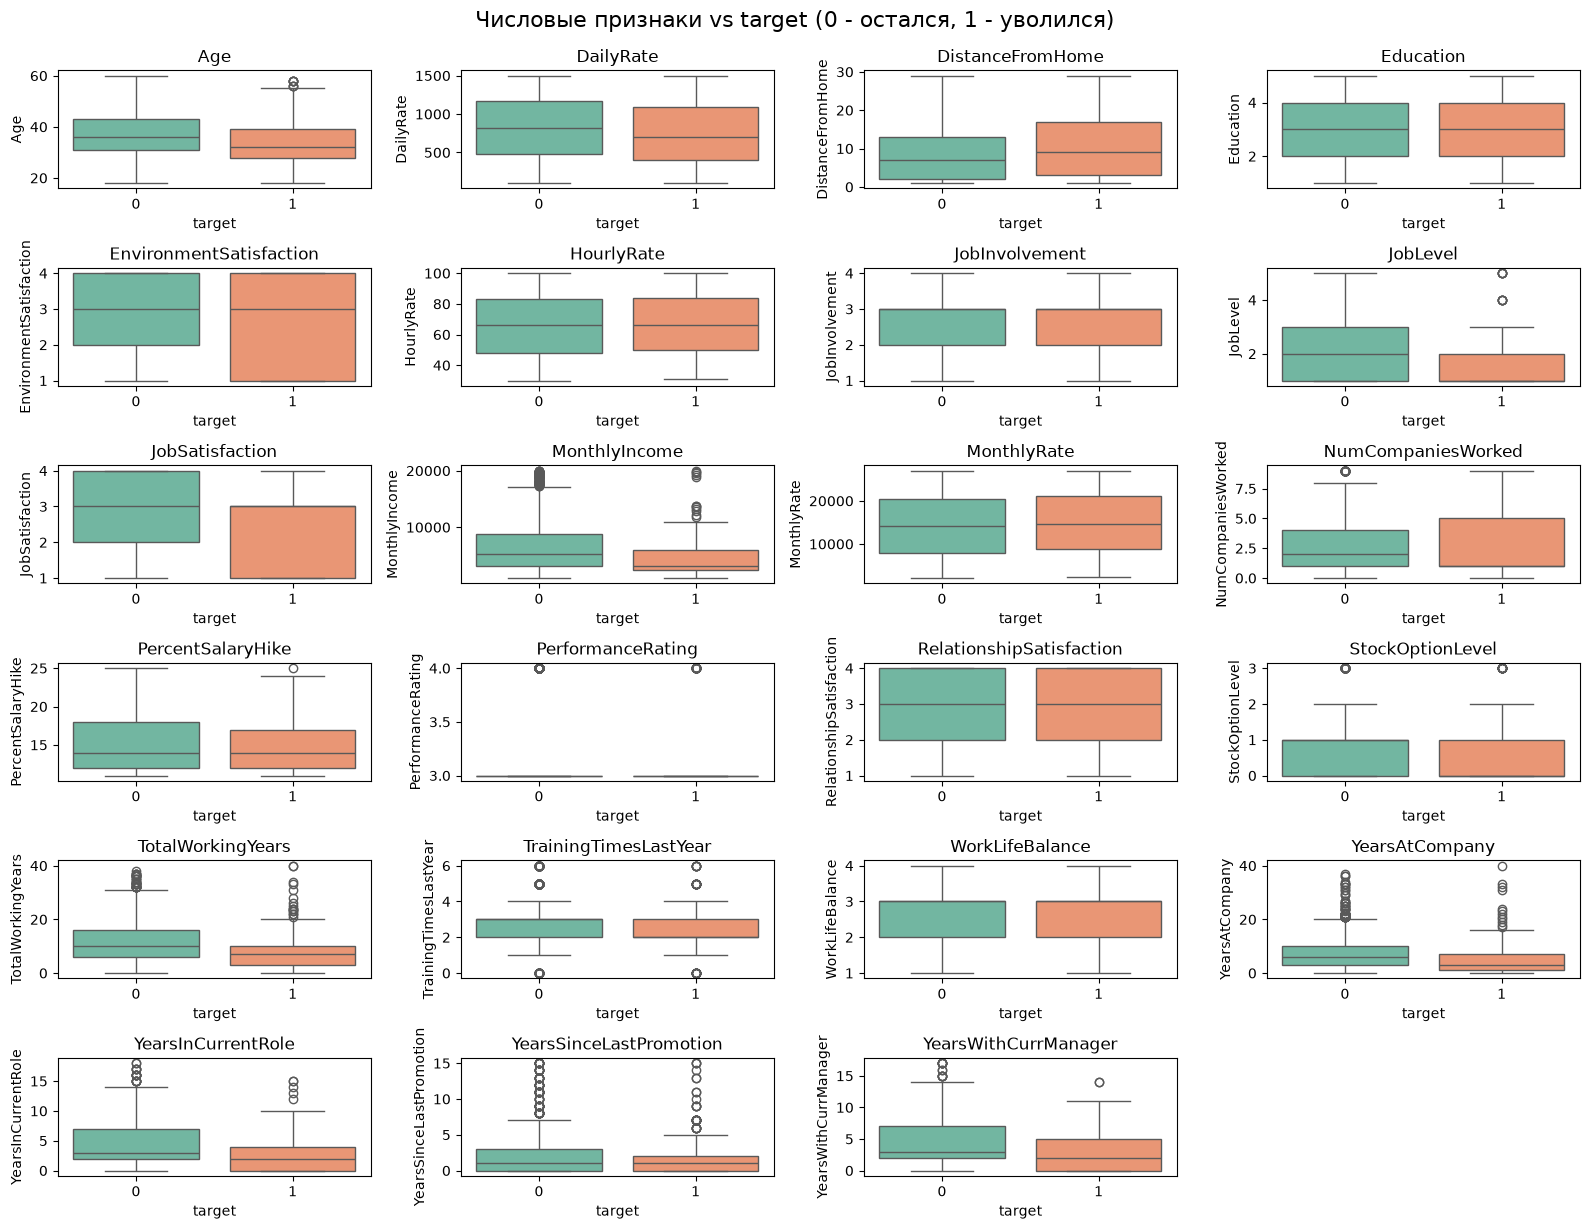

In [ ]:
fig, axes = plt.subplots(6, 4, figsize=(16, 12))
axes = axes.ravel()

num_cols_graph = NUM_COLS[NUM_COLS != 'target']


for i, col in enumerate(num_cols_graph):
    sns.boxplot(x='target', y=col, hue='target', data=df, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(col)
    
for j in range(len(num_cols_graph), len(axes)): axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Числовые признаки vs target (0 - остался, 1 - уволился)', y=1.02, fontsize=16)

plt.savefig('img/int_features.png', format='png', dpi=200, bbox_inches='tight')

plt.show()


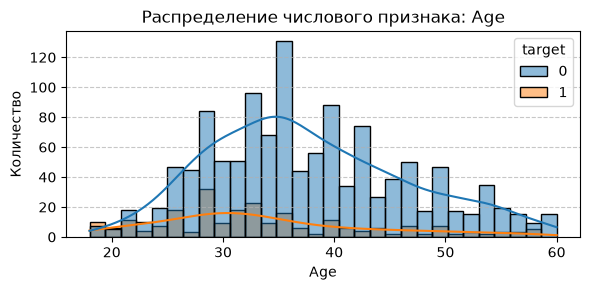

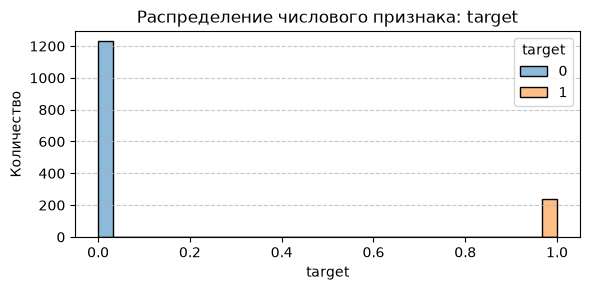

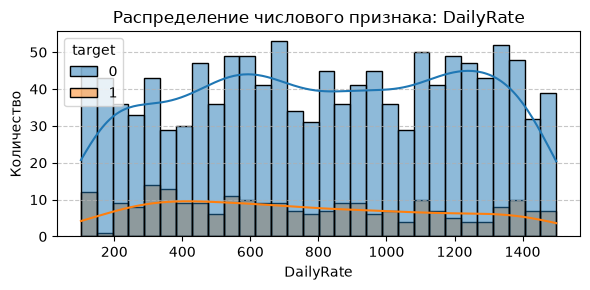

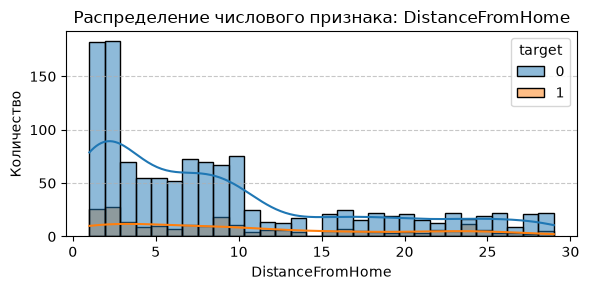

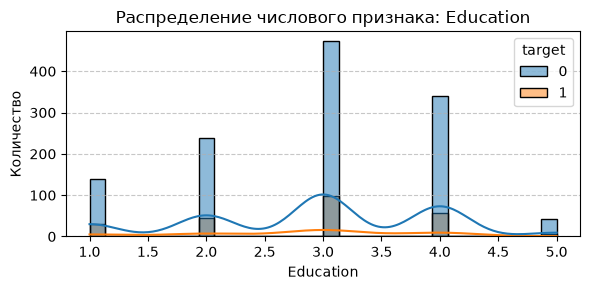

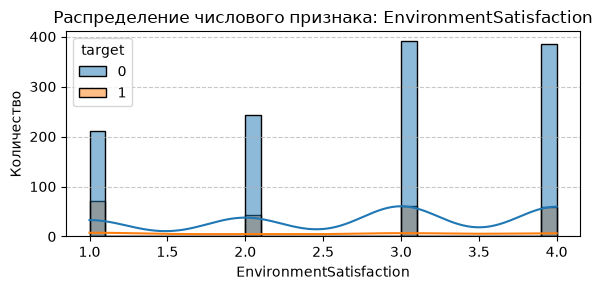

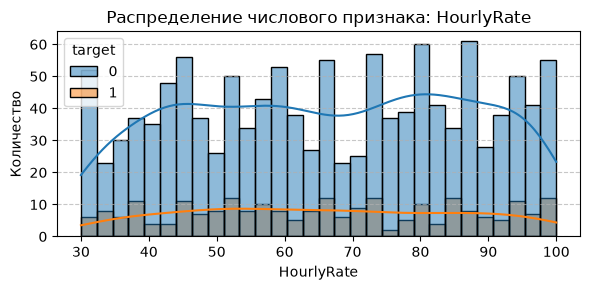

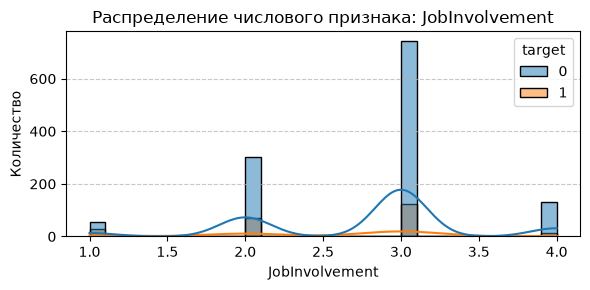

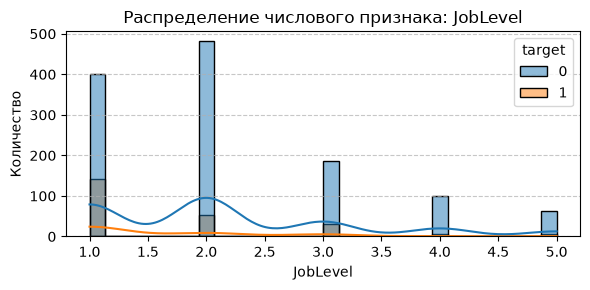

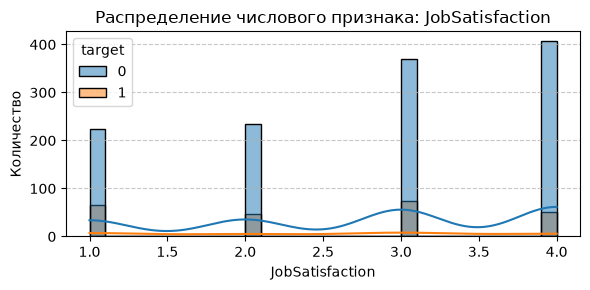

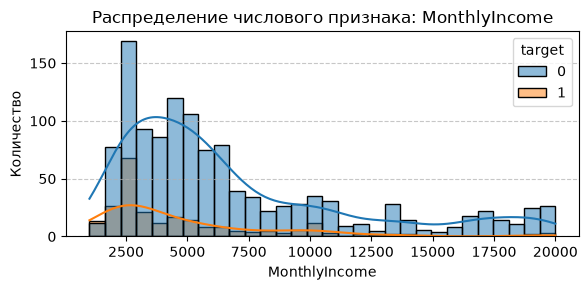

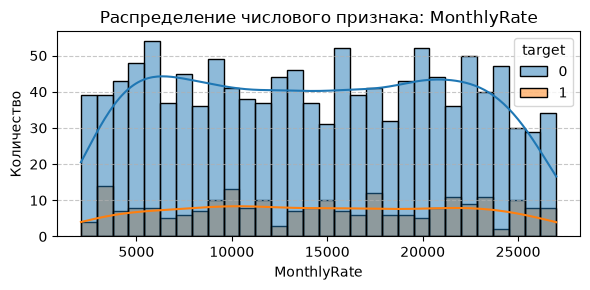

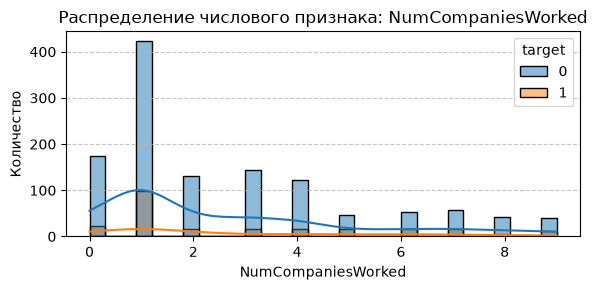

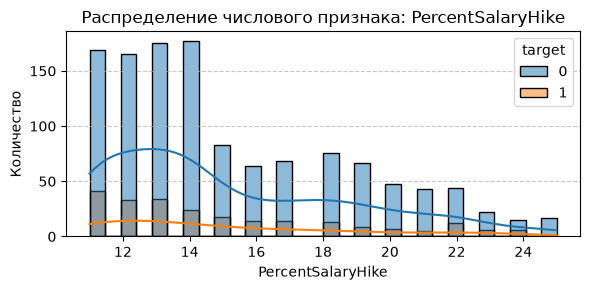

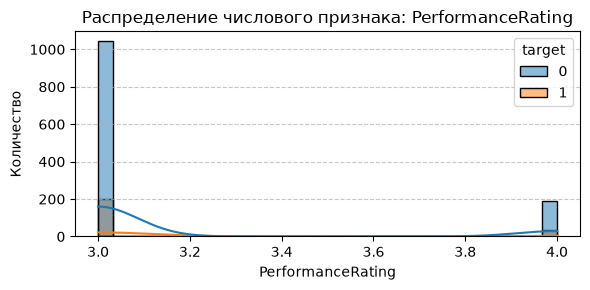

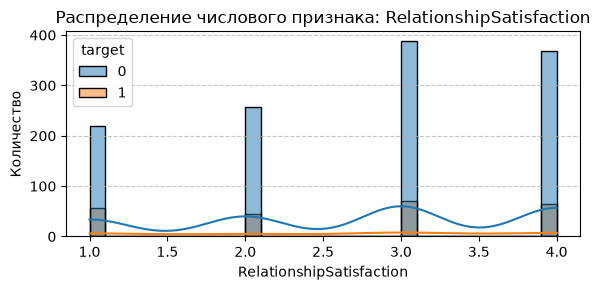

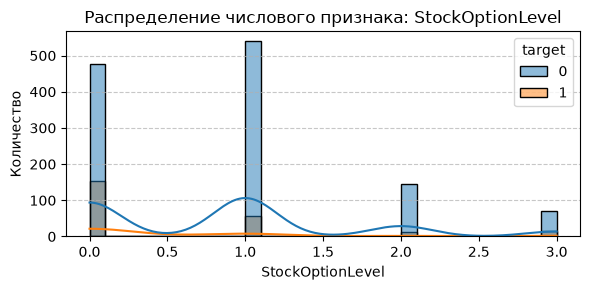

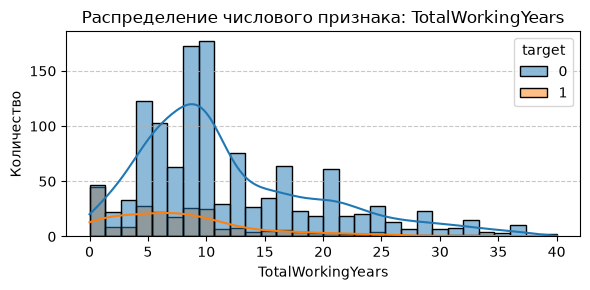

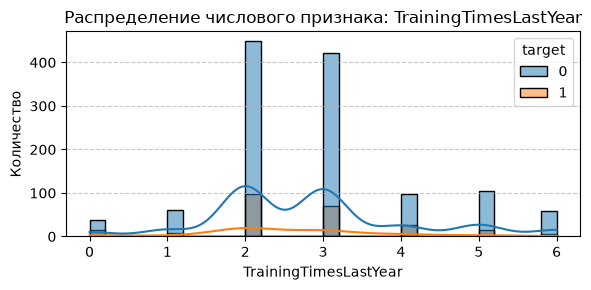

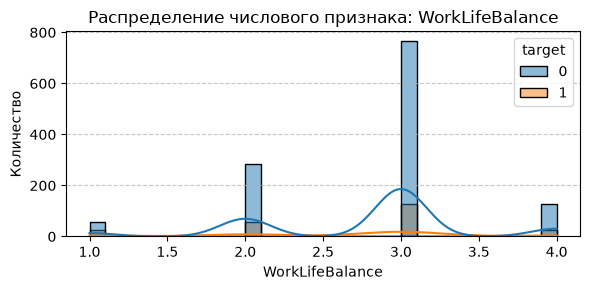

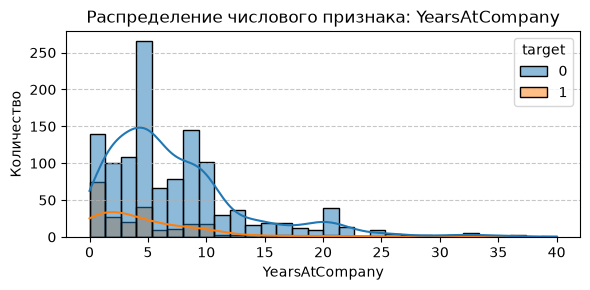

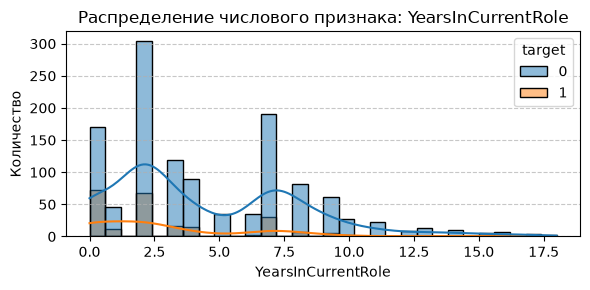

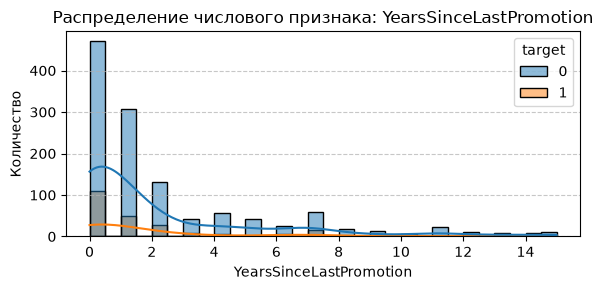

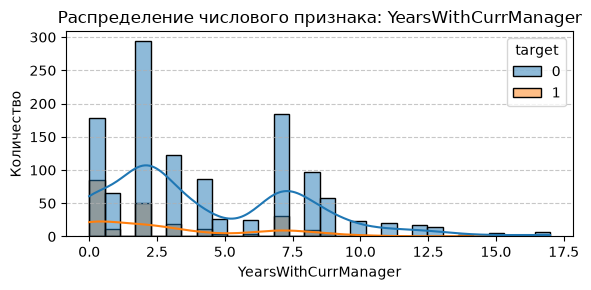

In [78]:
# Распределение числовых признаков

for col in NUM_COLS:
    plt.figure(figsize=(6, 3))
    sns.histplot(data=df, x=col, hue='target', bins=30, kde=True, alpha=0.5)
    plt.title(f'Распределение числового признака: {col}')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

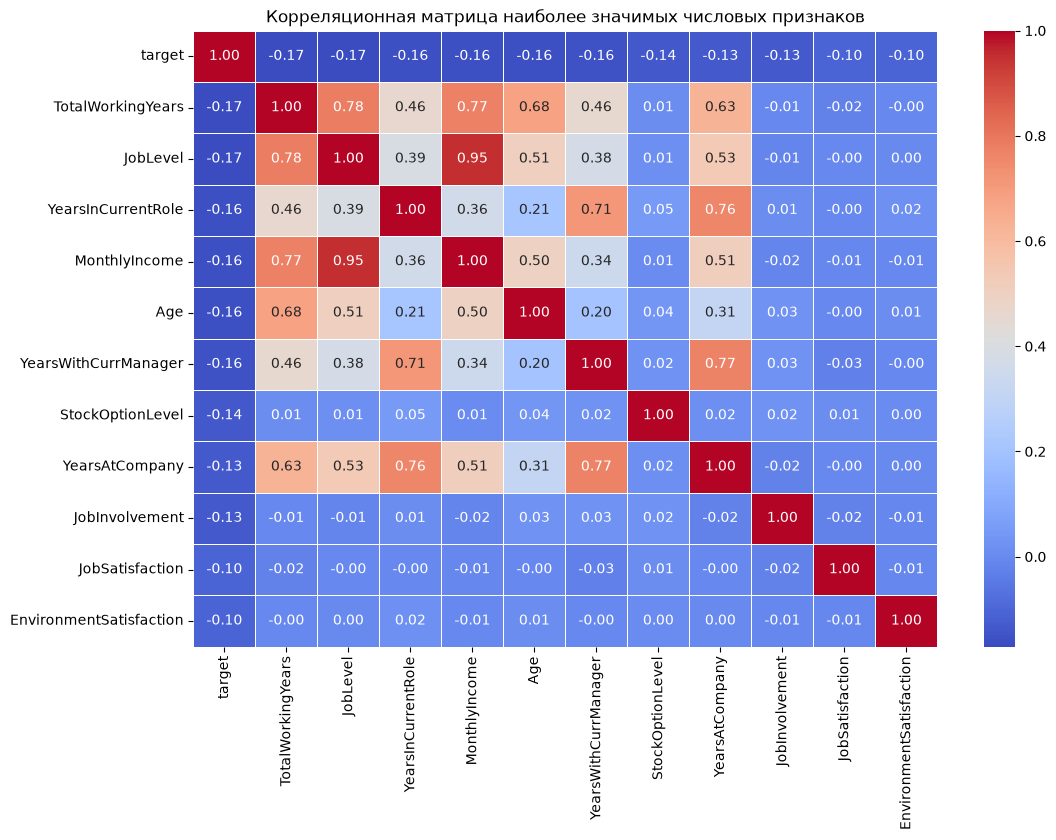


Топ корреляций с Attrition:
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: target, dtype: float64


In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12, 8))

# abs нужен только для отбора порога 0.1, знак сохраняем в corr для интерпретации
corr = numeric_df.corr()['target'].sort_values(ascending=False)
corr_with_target = corr.abs().sort_values(ascending=False)
relevant_cols = corr_with_target[corr_with_target > 0.1].index.tolist()
sns.heatmap(numeric_df[relevant_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица наиболее значимых числовых признаков')
plt.savefig('img/heatmap_corr.png', format='png', dpi=200, bbox_inches='tight')
plt.show()

print("\nТоп корреляций с Attrition:")
print(corr[relevant_cols[1:11]])

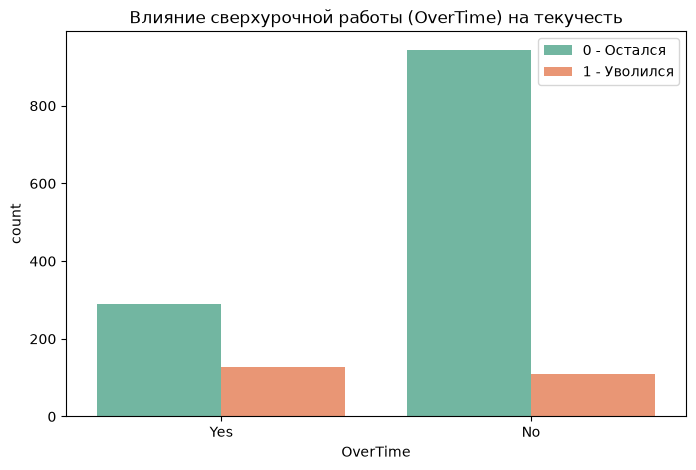

In [80]:
# Влияние категориального признака (Переработки)
plt.figure(figsize=(8, 5))
sns.countplot(x='OverTime', hue='target', data=df, palette='Set2')
plt.title('Влияние сверхурочной работы (OverTime) на текучесть')
plt.legend(['0 - Остался', '1 - Уволился'])
plt.show()

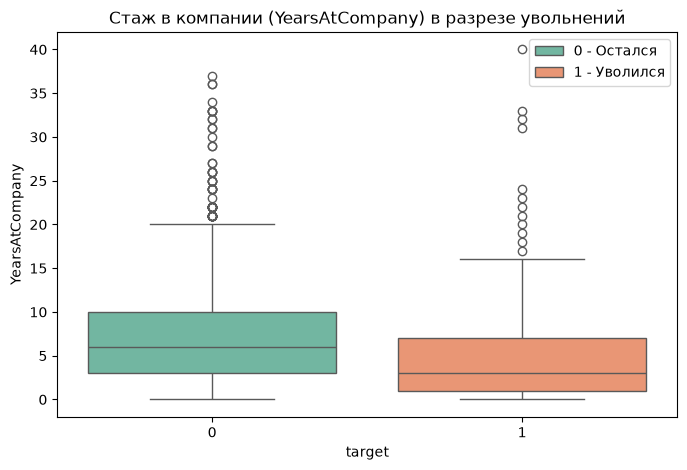

In [81]:
# Влияние числового признака (Стаж в компании)
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='YearsAtCompany', data=df, palette='Set2', hue='target')
plt.title('Стаж в компании (YearsAtCompany) в разрезе увольнений')
plt.legend(['0 - Остался', '1 - Уволился'])
plt.show()

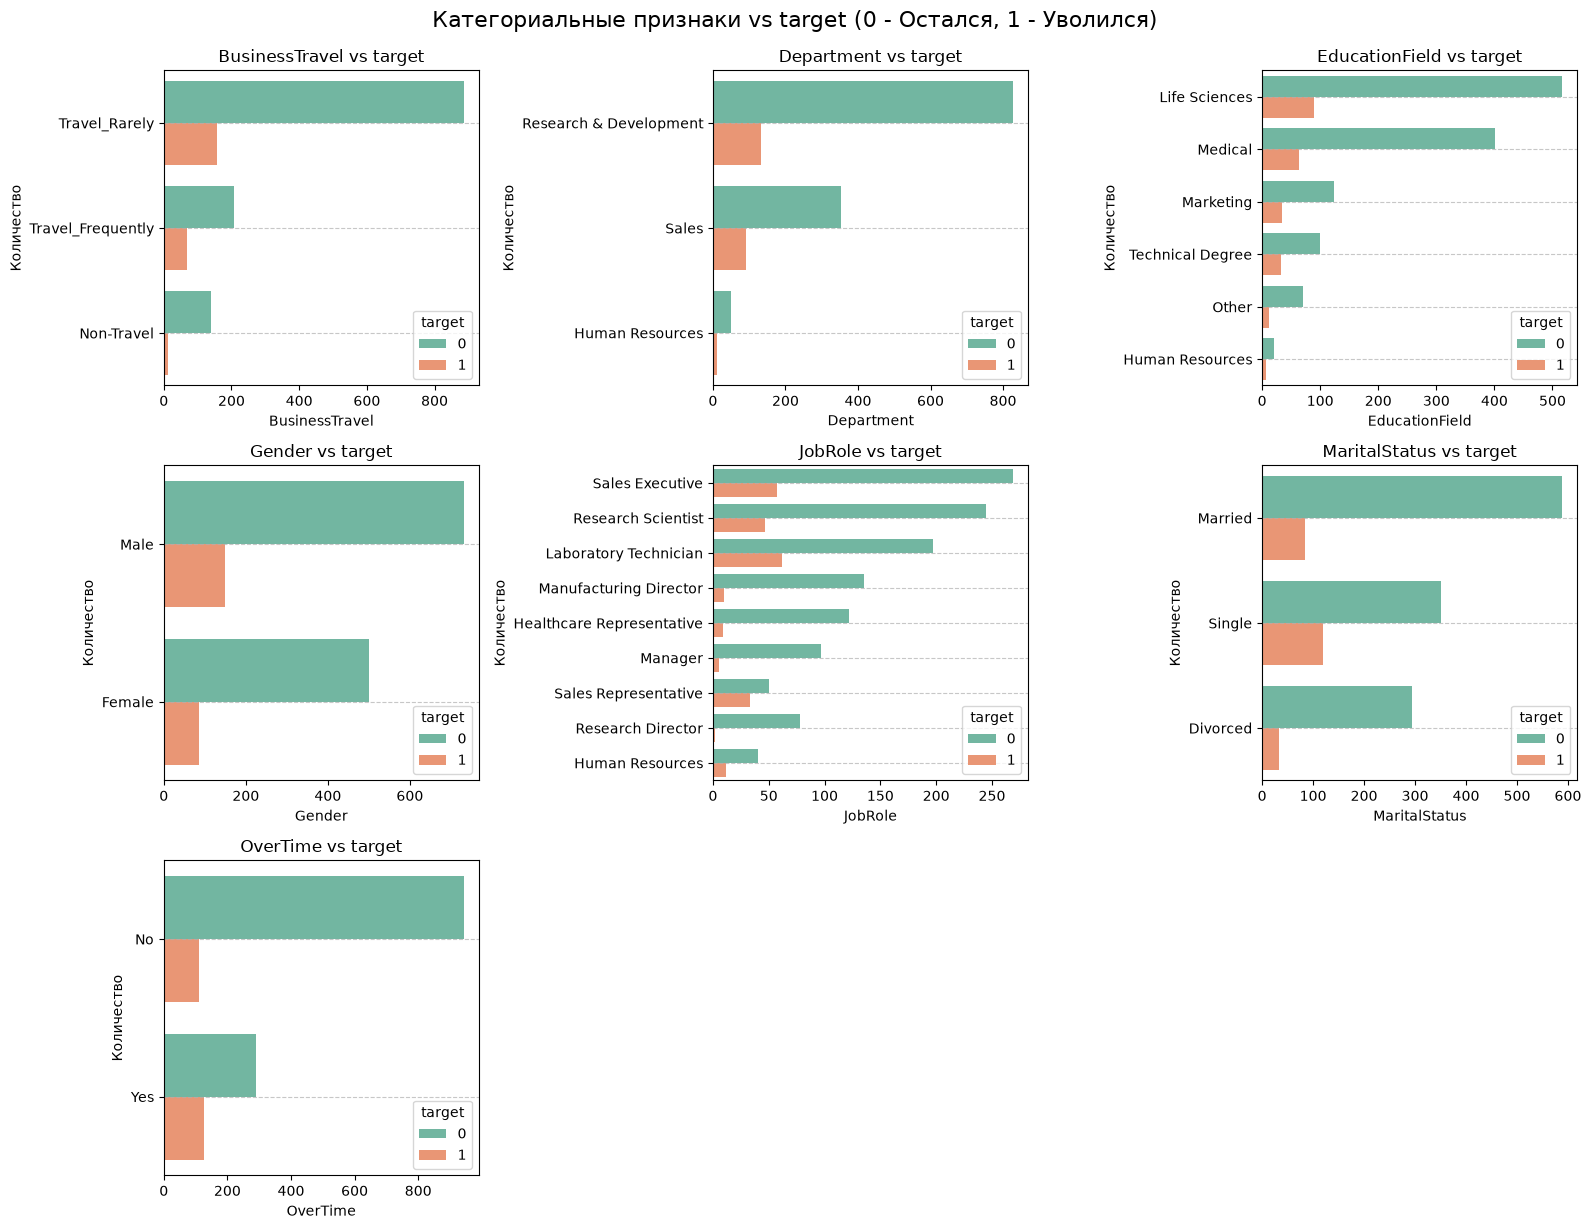


Доля увольнений по BusinessTravel:
BusinessTravel
Travel_Frequently    0.249
Travel_Rarely        0.150
Non-Travel           0.080
----------
Размеры групп:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150

Доля увольнений по Department:
Department
Sales                     0.206
Human Resources           0.190
Research & Development    0.138
----------
Размеры групп:
Department
Research & Development    961
Sales                     446
Human Resources            63

Доля увольнений по EducationField:
EducationField
Human Resources     0.259
Technical Degree    0.242
Marketing           0.220
Life Sciences       0.147
Medical             0.136
Other               0.134
----------
Размеры групп:
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27

Доля увольнений по Gender:
Gender
Male      0.170
Female    0.148
----------
Размеры групп

In [ ]:
# Расмотрим категориальные переменные

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(CAT_COLS):
    sns.countplot(
        data=df,
        y=col,
        hue='target',
        ax=axes[i],
        palette='Set2',
        order=df[col].value_counts().index,
    )
    axes[i].set_title(f'{col} vs target')
    axes[i].set_ylabel('Количество')
    #axes[i].tick_params(axis='x', labelrotation=35)
    axes[i].set_xlabel(col)
    axes[i].legend(title='target', loc='lower right')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Категориальные признаки vs target (0 - Остался, 1 - Уволился)', y=1.02, fontsize=16)
plt.savefig('img/categ_features.png', format='png', dpi=200, bbox_inches='tight')
plt.show()

# доля увольнений по каждой категории 
for col in CAT_COLS:
    attrition_rate = df.groupby(col)['target'].mean().sort_values(ascending=False)
    counts = df[col].value_counts()

    print(f"\nДоля увольнений по {col}:")
    print(attrition_rate.round(3).to_string())
    print('-'*10)
    print(f"Размеры групп:\n{counts.to_string()}")

## Общий вывод по ознакомлению с данными и визуализации
1. Изучали уже очищенный датасет `1470 строк x 31 колонка`, пропусков и дубликатов нет, целевая переменная бинаризована в `target 0/1` с сильным дисбалансом `0 — 83.9%, 1 — 16.1%`
2. Исходя из дисбаланса дальше обращаем больше внимание на метрики `F1/PR-AUC/recall`, а не на accuracy
3. Возраст сотрудника в среднем `36.9 лет`, доход и стаж сильно варьируются без явных выбросов, а ставки `Daily/Hourly/Monthly` являются шумными данными
4. Графики ящиков с усами числовые vs target показывают сдвиг у ушедших в сторону меньших значений признаков `TotalWorkingYears, JobLevel, MonthlyIncome, Age` и большего числа смен компаний. Знаки корреляции это подтверждают, все топ-10 отрицательные от `-0.17` до `-0.10`: дольше работаешь, выше грейд и доход — ниже риск ухода
5. Категориальные срезы дают главные группы риска: 
    - OverTime `Yes 30.5%` против `No 10.4%`
    - Travel_Frequently `24.9%` против Non-Travel `8.0%`
    - Sales `20.6%` и HR `19.0%` против R&D `13.8%`
6. По должностям выделяются `Sales Representative 39.8%` и `Laboratory Technician 23.9%`, по сферам образования — `Human Resources 25.9%` и `Technical Degree 24.2%` при маленьких группах.
7. В дальнейшем всю информацию нужно учесть для подбора моделей и гиперпараметров, таких как `stratify`, `class_weight='balanced'`
8. Подготовлены графики `img/distribution_target.png, int_features.png, heatmap_corr.png, categ_features.png` для отчета
